In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from pib_helper import compute_energy

<a id="part1"></a>
## Part 1 - Numerically Solving the Schrodinger Equation

**The Schrodinger Equation and Energy**

Suppose we wanted to calculate the energy of an electron. What would we do?

Well, we can use the *Time-Independent Schrodinger Equation*, which tells us that the total energy of our wavefunction is the sum of the potential and kinetic energies.
$$
\hat{H} \psi{}(x) = \hat{T}\psi{}(x)  + \hat{V}(x)\psi(x)
$$
Where $\psi{}(x)$ is the wavefunction, $\hat{H}$ is the Hamiltonian (i.e. the Energy operator), $\hat{T}$ is the kinetic energy operator, and $\hat{V}(x)$ is the potential energy (as a function of x).


**Eigenvalues and Eigenfunctions**

For a wavefunction to have a clearly defined energy, it must satisfy: 
$$ \hat{H}\psi = E \psi $$
Where $E$ is constant. 

In these special cases, we say that $\psi$ is an _eigenfunction_ of the energy operator $\hat{H}$, and the observed energy $E$ is an _eigenvalue_. Okay, great. If you want the wavefunction of a system, just find the eigenvalues of the Schrodinger Equation. And in fact, we can do that for the particle-in-a-box, as you may have learned in lecture.

**Numerical Solutions**

Most real chemical systems, however, do *not* admit closed-form solutions. For real molecules, potentials are complicated, electrons interact, and analytic expressions are rarely obtainable. In practice, chemists often rely on numerical methods to discover physically meaningful solutions rather than writing them down algebraically.

To see how this works in a controlled setting, we will approach the particle-in-a-box problem *numerically*, instead of *analytically* (like you may have in lecture). 

Instead of solving for the eigenfunction directly, we define a quantity that measures how “energetically costly” a candidate wavefunction is and minimize it. One useful choice is the average value (expectation value) of the energy, which is well-defined even for non-eigenfunctions:
$$
\braket{E} = \frac{\int_0^L \psi^*(x)\hat{H}\psi(x) dx}{\int_0^L |\psi(x)|^2 dx}.
$$
Where $\hat{H} = \hat{T} =  -\frac{\hbar{}}{2m}\frac{d^2}{dx^2}$ for the particle-in-a-box system.

The numerator measures energy and the denominator ensures normalization. Minimizing E is equivalent to asking: Among all functions that satisfy the boundary conditions, which one has the lowest kinetic energy?

---

## Coding Activity 1
`25 points`

- C4.1: Solve the Schrödinger equation for an electron using numerical methods.
- P4.1: Perform numerical optimization routines with `scipy`.



### Part A — Calculate Energies For Trial Wavefunctions

Write at least three different trial functions for $\psi(x)$ that satisfy the boundary conditions $\psi(0) = \psi(L) = 0$. Some ideas:
- A polynomial like $x(L - x)$
- A Gaussian multiplied by $x(L - x)$
- A sine wave that satisfies the boundary conditions like $sin(\frac{\pi{}}{L}x)$

Each function should take an array `x` as input and return an array of the same shape.

For each trial function:
1. Plot it using the `plot_trial` function defined below.
2. Compute its energy using `compute_energy` from the helper.
3. Record which function has the lowest energy.

In [48]:
# --- Given: plotting utility ---
# This function plots a trial wavefunction on a box of length L.
# You can read through this to see how it works, but you don't need to modify it.
def plot_wavefunction(x, y, label=None):
    """Plot a trial wavefunction and shade the box region."""
    if not abs(y[0]) < 0.0001 or not abs(y[-1]) < 0.0001:
        raise ValueError("Trial wavefunction must satisfy boundary conditions (psi(0) = psi(L) = 0).")
    # evaluate energy
    E = compute_energy(y, x)
    plt.plot(x, y, label=label + f" (E={E:.3f})")
    plt.axhline(0, color='grey', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.4)
    plt.axvline(x[-1], color='black', linewidth=1, linestyle='--', alpha=0.4)
    plt.xlabel('x')
    plt.ylabel(r'$\psi(x)$')
    plt.title('Wavefunctions & Energies')
    plt.legend()

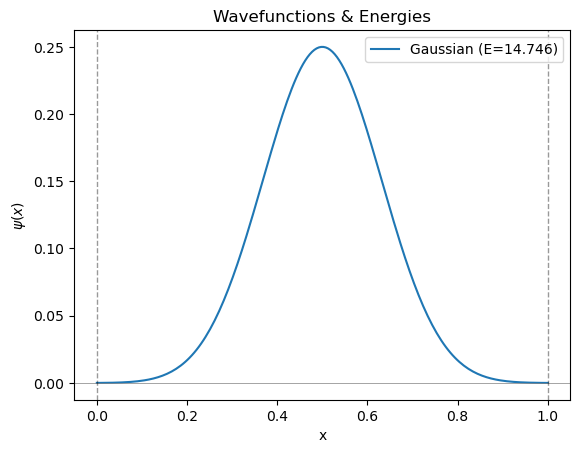

In [49]:
L = 1.0
x = np.linspace(0, L, 200)

# Example: Gaussian bump (provided)
def gaussian(x):
    center, width = 0.5, 0.2
    return np.exp(-((x - center)**2) / width**2) * (x * (L - x))  # Ensure it goes to zero at boundaries


plot_wavefunction(x, gaussian(x), label='Gaussian')

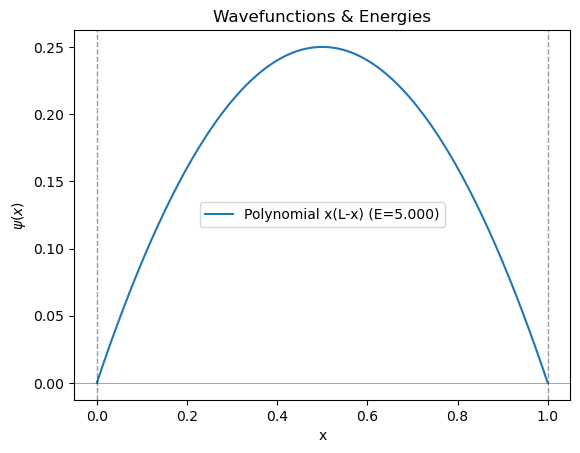

In [50]:
# try another function and plot it!
def polynomial(x):
    # x*(L-x) is zero at both boundaries by construction
    return x * (L - x)

plot_wavefunction(x, polynomial(x), label='Polynomial x(L-x)')

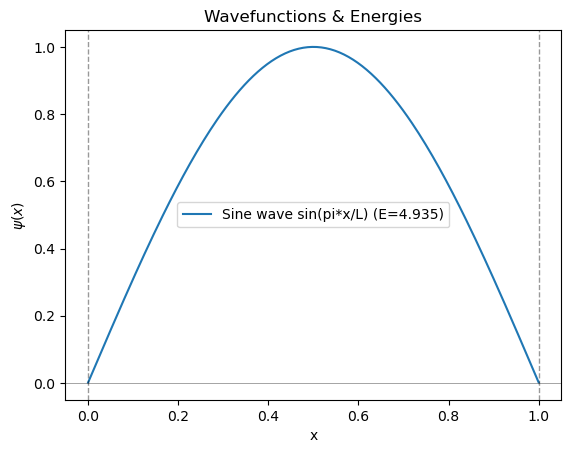

In [51]:
# one more!

def sine_wave(x):
    # A sine wave that satisfies the boundary conditions
    return np.sin(np.pi * x / L)

plot_wavefunction(x, sine_wave(x), label='Sine wave sin(pi*x/L)')

#### Part B — Optimizing wavefunctions

You've constructed several guess wavefunctions and evaluated their energies. Imagine you wanted to find the wavefunction which had the lowest energy. How would you approach this?

Rather than try different functional forms by hand, we can just use our energy functional and our guess wavefunctions to **optimize** the wavefunction! 

**Your task:**

- Use `scipy.optimize.minimize` to find the wavefunction that minimizes the energy.
- Plot the wavefunction before and after minimization using plot_wavefunction().
- **Leave comments explaining the worked example.**

(Hint: It will help you to write down the names of the functions you created as a reference for this part)

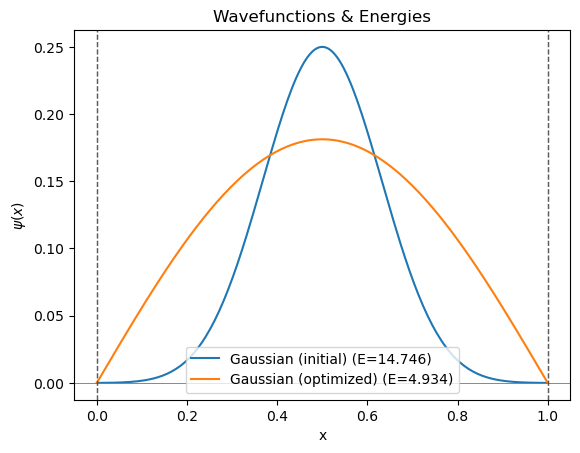

In [52]:
# Subgoal: Minimize energy for the Gaussian trial function

y_guess = gaussian(x)  #YOUR COMMENT HERE
result_gauss = minimize(compute_energy, y_guess, args=(x,), method='CG')  #YOUR COMMENT HERE
#the variable name 'x' is confusing here. it is really the y values, but this is the convention minimize uses.
phi_gauss_opt = result_gauss.x # YOUR COMMENT HERE
plot_wavefunction(x, y_guess, label='Gaussian (initial)')                       #YOUR COMMENT HERE
plot_wavefunction(x, phi_gauss_opt, label='Gaussian (optimized)')
plt.show()

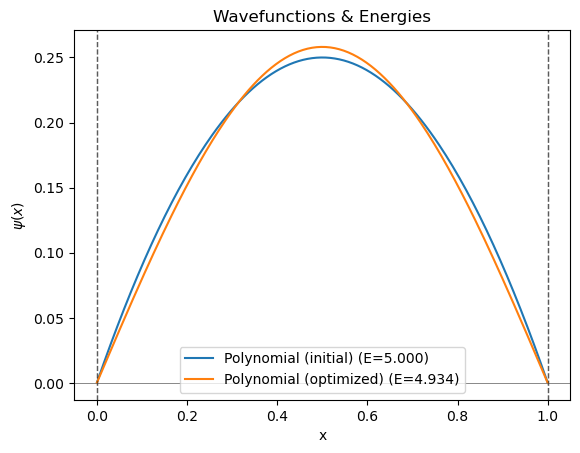

In [53]:
# Subgoal: Use your second trial function as a guess. Plot them before and after optimization.

y_guess = polynomial(x)
result_poly = minimize(compute_energy, y_guess, args=(x,), method='CG')
phi_poly_opt = result_poly.x
plot_wavefunction(x, y_guess, label='Polynomial (initial)')
plot_wavefunction(x, phi_poly_opt, label='Polynomial (optimized)')
plt.show()

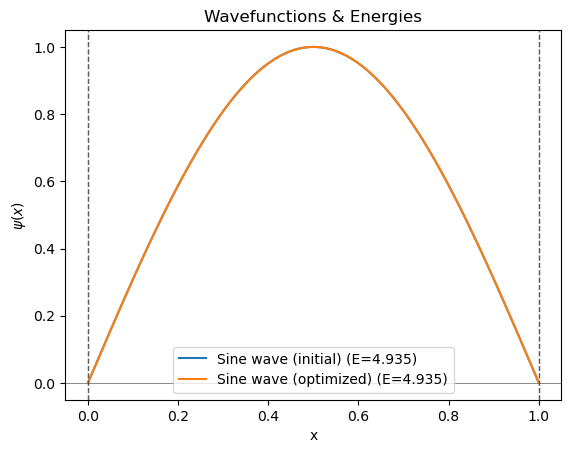

In [55]:
# sine wave
y_guess = sine_wave(x)
result_sine = minimize(compute_energy, y_guess, args=(x,), method='CG')
phi_sine_opt = result_sine.x
plot_wavefunction(x, y_guess, label='Sine wave (initial)')
plot_wavefunction(x, phi_sine_opt, label='Sine wave (optimized)')
plt.show()

### Question 1
`15 points`

- C4.1: Solve the Schrödinger equation for an electron using numerical methods.

a) Did the converged result of minimization depend on your initial guess? If so, why do you think this is?

b) Were there any functions for which the energy (and function) remained unchanged after optimization? If so, what does this tell you about that function?

c) Explain how this technique might be useful for real chemical systems where no analytic solution exists.

---

**Model answers:**


---